In [1]:
import libraries as lb

In [2]:
consumption_data = lb.pd.read_csv("Dataset/consumption_facility_cleaned.csv")
consumption_data["Stockout_Flag"].value_counts()

Stockout_Flag
False    10795
True       316
Name: count, dtype: int64

# P(Stockout_Flag = 1) by Region

In [3]:
#  P(Stockout_Flag = 1) by Region 
stockout_prob = consumption_data.groupby('Region').agg(
    Total_Records=('Stockout_Flag', 'count'),
    Stockout_Count=('Stockout_Flag', 'sum')
).reset_index()
stockout_prob['P_Stockout'] = (
    stockout_prob['Stockout_Count'] / 
    stockout_prob['Total_Records']
).round(4)
stockout_prob = stockout_prob.sort_values('P_Stockout', ascending=False)
print(stockout_prob.to_string())

         Region  Total_Records  Stockout_Count  P_Stockout
4    Coimbatore            423              18      0.0426
15        Patna            230               9      0.0391
8        Indore            662              25      0.0378
14       Nagpur            623              23      0.0369
9        Jaipur            554              20      0.0361
0     Ahmedabad            699              24      0.0343
6      Guwahati            426              14      0.0329
5         Delhi            683              21      0.0307
16         Pune            699              21      0.0300
13       Mumbai           1394              39      0.0280
12      Lucknow            728              19      0.0261
17       Raipur            174               4      0.0230
1     Bangalore            664              15      0.0226
3       Chennai            854              19      0.0222
2   Bhubaneswar            227               5      0.0220
7     Hyderabad            933              20      0.02

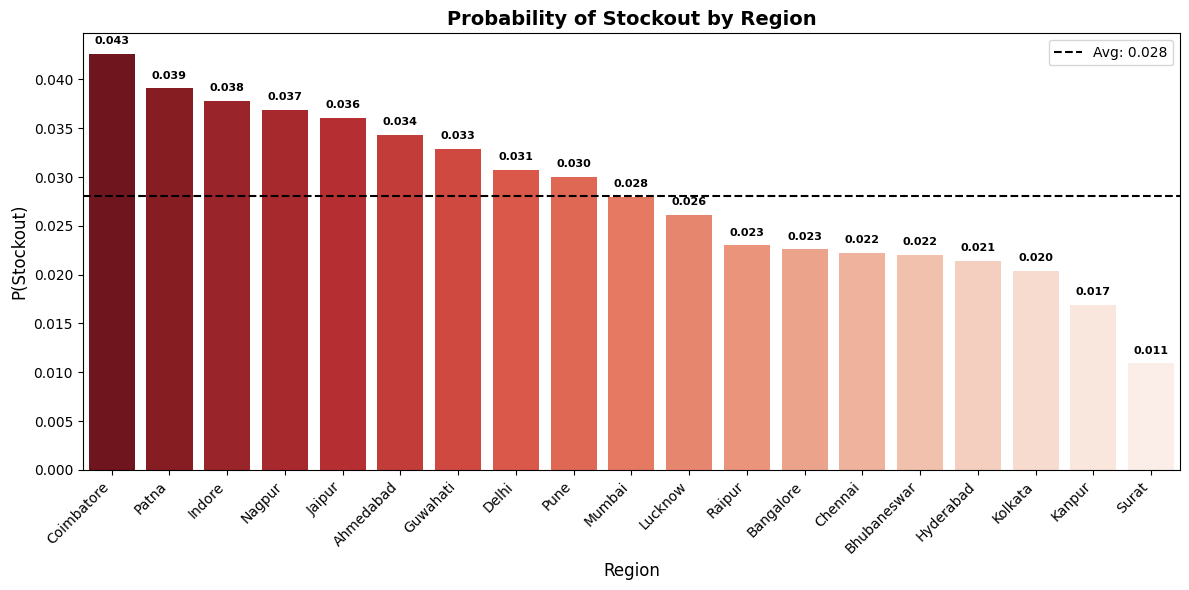

In [4]:
# Plot 
lb.plt.figure(figsize=(12, 6))
lb.sns.barplot(data=stockout_prob,
               x='Region',
               y='P_Stockout',
               palette='Reds_r')

for i, row in stockout_prob.reset_index().iterrows():
    lb.plt.text(i, row['P_Stockout'] + 0.001,
                f"{row['P_Stockout']:.3f}",
                ha='center', fontsize=8, fontweight='bold')

lb.plt.axhline(y=stockout_prob['P_Stockout'].mean(),
               color='black', linestyle='--',
               label=f"Avg: {stockout_prob['P_Stockout'].mean():.3f}")

lb.plt.title('Probability of Stockout by Region',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Region', fontsize=12)
lb.plt.ylabel('P(Stockout)', fontsize=12)
lb.plt.xticks(rotation=45, ha='right')
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

## Probability 1 — P(Stockout) by Region

**Coimbatore (0.043)** highest stockout risk smaller cities outrank metros surprisingly.

**Patna, Indore, Nagpur** follow weaker supply chains in smaller cities.

**Mumbai (0.028)** at average despite highest total count large volume dilutes probability.

**Surat (0.011)** lowest risk best supply availability.

**Avg P(Stockout) = 0.028** 3% of all medicine records face stockout risk.

**Key Insight:** 
    
Smaller cities need stronger regional supply chain support.

# Probability 2 — P(Wastage) by Region

In [5]:
consumption_data['Wastage_Flag'] = (
    consumption_data['Wastage_Units'] > 0
).astype(int)

print("Wastage_Flag value counts:")
print(consumption_data['Wastage_Flag'].value_counts())

wastage_prob = consumption_data.groupby('Region').agg(
    Total_Records=('Wastage_Flag', 'count'),
    Wastage_Count=('Wastage_Flag', 'sum')
).reset_index()

wastage_prob['P_Wastage'] = (
    wastage_prob['Wastage_Count'] /
    wastage_prob['Total_Records']
).round(4)

wastage_prob = wastage_prob.sort_values('P_Wastage', ascending=False)
print(wastage_prob.to_string())

Wastage_Flag value counts:
Wastage_Flag
0    9522
1    1589
Name: count, dtype: int64
         Region  Total_Records  Wastage_Count  P_Wastage
10       Kanpur            178             31     0.1742
5         Delhi            683            114     0.1669
4    Coimbatore            423             69     0.1631
16         Pune            699            114     0.1631
6      Guwahati            426             69     0.1620
2   Bhubaneswar            227             36     0.1586
17       Raipur            174             26     0.1494
7     Hyderabad            933            139     0.1490
8        Indore            662             97     0.1465
13       Mumbai           1394            204     0.1463
9        Jaipur            554             81     0.1462
3       Chennai            854            122     0.1429
0     Ahmedabad            699             96     0.1373
14       Nagpur            623             83     0.1332
15        Patna            230             29     0.1261
11

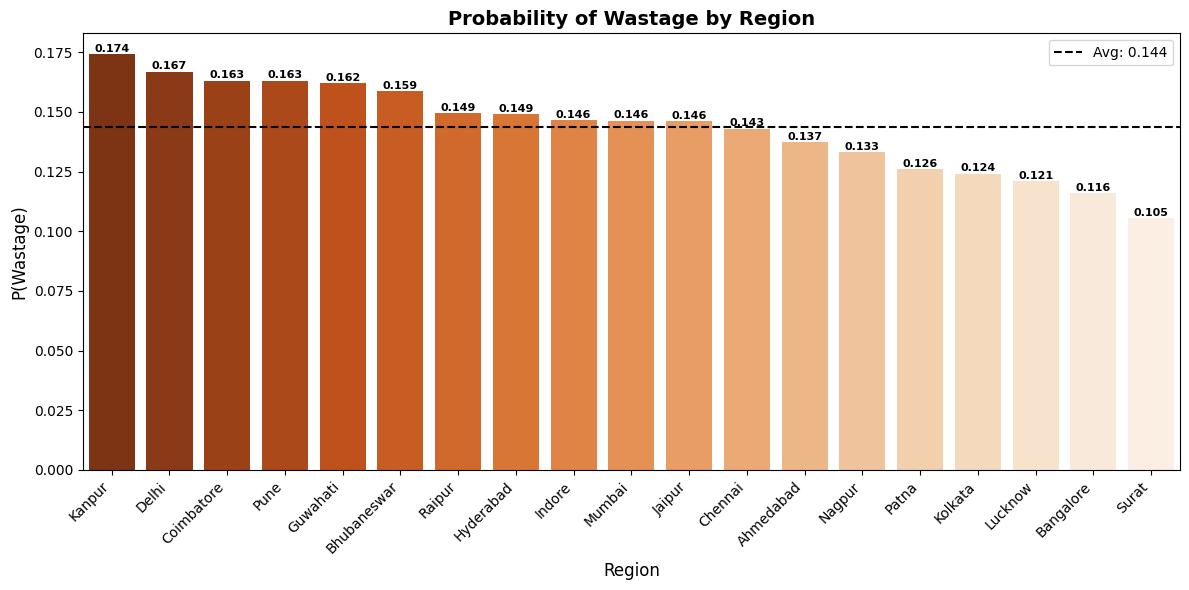

In [6]:
# Plot
lb.plt.figure(figsize=(12, 6))
lb.sns.barplot(data=wastage_prob,
               x='Region',
               y='P_Wastage',
               palette='Oranges_r')

for i, row in wastage_prob.reset_index().iterrows():
    lb.plt.text(i, row['P_Wastage'] + 0.001,
                f"{row['P_Wastage']:.3f}",
                ha='center', fontsize=8, fontweight='bold')

lb.plt.axhline(y=wastage_prob['P_Wastage'].mean(),
               color='black', linestyle='--',
               label=f"Avg: {wastage_prob['P_Wastage'].mean():.3f}")

lb.plt.title('Probability of Wastage by Region',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Region', fontsize=12)
lb.plt.ylabel('P(Wastage)', fontsize=12)
lb.plt.xticks(rotation=45, ha='right')
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

## Probability 2 — P(Wastage) by Region

**Kanpur (0.174)** highest wastage probability.

**Surat (0.105)** lowest best utilization.

**Avg P(Wastage) = 0.144** 5x higher than stockout probability (0.028).

**Key Insight:** 

Wastage is a far bigger problem than stockout across all regions.

# Probability — P(Stockout Risk) by Category

In [7]:
inventory_data = lb.pd.read_csv("Dataset/inventory_stock_cleaned.csv")

print("Stockout_Risk value counts:")
print(inventory_data['Stockout_Risk'].value_counts())

# ── P(Stockout_Risk = 1) by Category ───────────────────
stockout_cat = inventory_data.groupby('Category').agg(
    Total_Records=('Stockout_Risk', 'count'),
    Stockout_Count=('Stockout_Risk', 'sum')
).reset_index()

stockout_cat['P_Stockout_Risk'] = (
    stockout_cat['Stockout_Count'] /
    stockout_cat['Total_Records']
).round(4)

stockout_cat = stockout_cat.sort_values('P_Stockout_Risk', ascending=False)
print(stockout_cat.to_string())

Stockout_Risk value counts:
Stockout_Risk
False    819
True      22
Name: count, dtype: int64
            Category  Total_Records  Stockout_Count  P_Stockout_Risk
4         Parenteral            181               7           0.0387
0  Bulk/Raw Material             26               1           0.0385
3              Other            445              11           0.0247
1               Oral            186               3           0.0161
2        Oral Liquid              3               0           0.0000


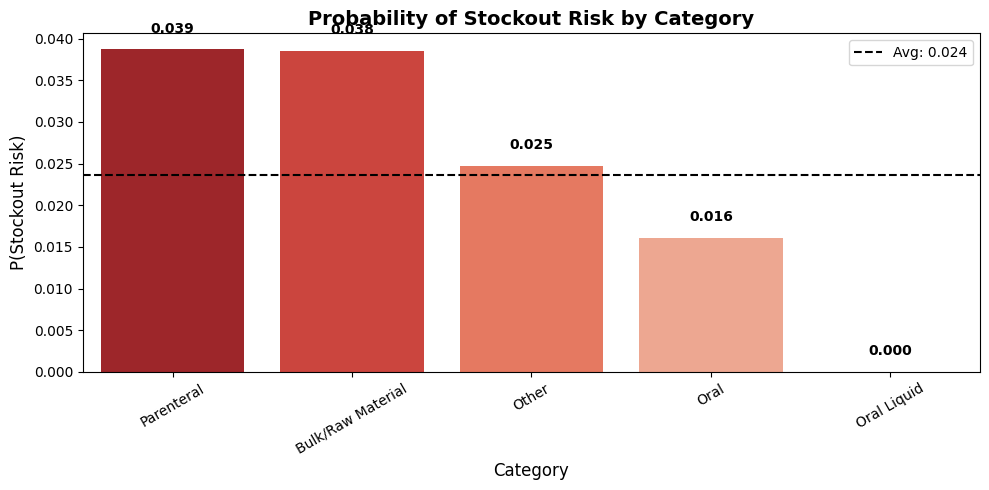

In [8]:
# Plot
lb.plt.figure(figsize=(10, 5))
lb.sns.barplot(data=stockout_cat,
               x='Category',
               y='P_Stockout_Risk',
               palette='Reds_r')

for i, row in stockout_cat.reset_index().iterrows():
    lb.plt.text(i, row['P_Stockout_Risk'] + 0.002,
                f"{row['P_Stockout_Risk']:.3f}",
                ha='center', fontsize=10, fontweight='bold')

lb.plt.axhline(y=stockout_cat['P_Stockout_Risk'].mean(),
               color='black', linestyle='--',
               label=f"Avg: {stockout_cat['P_Stockout_Risk'].mean():.3f}")

lb.plt.title('Probability of Stockout Risk by Category',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Category', fontsize=12)
lb.plt.ylabel('P(Stockout Risk)', fontsize=12)
lb.plt.xticks(rotation=30)
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

## Probability — P(Stockout Risk) by Category

**Parenteral (0.039)** & **Bulk/Raw (0.038)** highest risk critical medicines vulnerable.
**Oral Liquid (0.000)** zero risk, well managed.
**Key Insight:** 

Parenteral needs immediate restocking priority.

## Probability — P(Expiry Risk) by Category

In [9]:
expiry_cat = inventory_data.groupby('Category').agg(
    Total_Records=('Expiry_Risk', 'count'),
    Expiry_Count=('Expiry_Risk', 'sum')
).reset_index()

expiry_cat['P_Expiry_Risk'] = (
    expiry_cat['Expiry_Count'] /
    expiry_cat['Total_Records']
).round(4)

expiry_cat = expiry_cat.sort_values('P_Expiry_Risk', ascending=False)
print(expiry_cat.to_string())

            Category  Total_Records  Expiry_Count  P_Expiry_Risk
4         Parenteral            181           167         0.9227
1               Oral            186             1         0.0054
0  Bulk/Raw Material             26             0         0.0000
2        Oral Liquid              3             0         0.0000
3              Other            445             0         0.0000


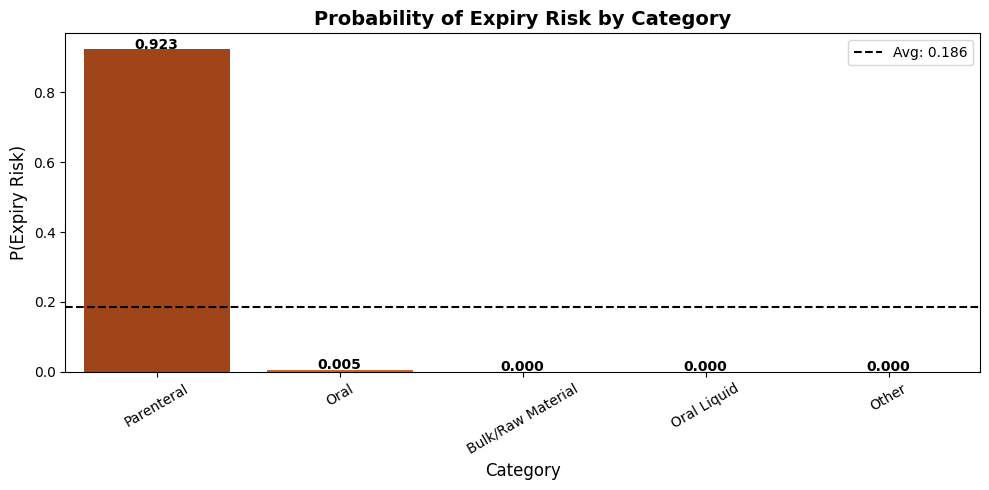

In [10]:
# Plot 
lb.plt.figure(figsize=(10, 5))
lb.sns.barplot(data=expiry_cat,
               x='Category',
               y='P_Expiry_Risk',
               palette='Oranges_r')

for i, row in expiry_cat.reset_index().iterrows():
    lb.plt.text(i, row['P_Expiry_Risk'] + 0.002,
                f"{row['P_Expiry_Risk']:.3f}",
                ha='center', fontsize=10, fontweight='bold')

lb.plt.axhline(y=expiry_cat['P_Expiry_Risk'].mean(),
               color='black', linestyle='--',
               label=f"Avg: {expiry_cat['P_Expiry_Risk'].mean():.3f}")

lb.plt.title('Probability of Expiry Risk by Category',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Category', fontsize=12)
lb.plt.ylabel('P(Expiry Risk)', fontsize=12)
lb.plt.xticks(rotation=30)
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

## Observations

**Parenteral (0.923)** 92.3% of injectable medicines at expiry risk! Extremely alarming.

**Oral (0.005)** minimal risk.

**Bulk/Raw, Oral Liquid, Other (0.000)** zero expiry risk.

**Key Insight:** 

Nearly all Parenteral medicines are expiring overstocked and unused, causing massive financial loss. Urgent action needed.

# Probability — P(Poor Performance) by Supplier Region

In [11]:
supplier_data = lb.pd.read_csv("Dataset/supplier_procurement_cleaned.csv")

print("\nPoor_Performance value counts:")
print(supplier_data['Poor_Performance'].value_counts())

# P(Poor_Performance = 1) by Region
poor_perf = supplier_data.groupby('Region').agg(
    Total_Records=('Poor_Performance', 'count'),
    Poor_Count=('Poor_Performance', 'sum')
).reset_index()

poor_perf['P_Poor_Performance'] = (
    poor_perf['Poor_Count'] /
    poor_perf['Total_Records']
).round(4)

poor_perf = poor_perf.sort_values('P_Poor_Performance', ascending=False)
print(poor_perf.to_string())


Poor_Performance value counts:
Poor_Performance
False    430
True     108
Name: count, dtype: int64
      Region  Total_Records  Poor_Count  P_Poor_Performance
1    Chennai             62          15              0.2419
2      Delhi             72          17              0.2361
6     Mumbai             79          18              0.2278
7       Pune             67          14              0.2090
3  Hyderabad             59          12              0.2034
0  Bangalore             72          14              0.1944
4    Kolkata             55           9              0.1636
5    Lucknow             72           9              0.1250


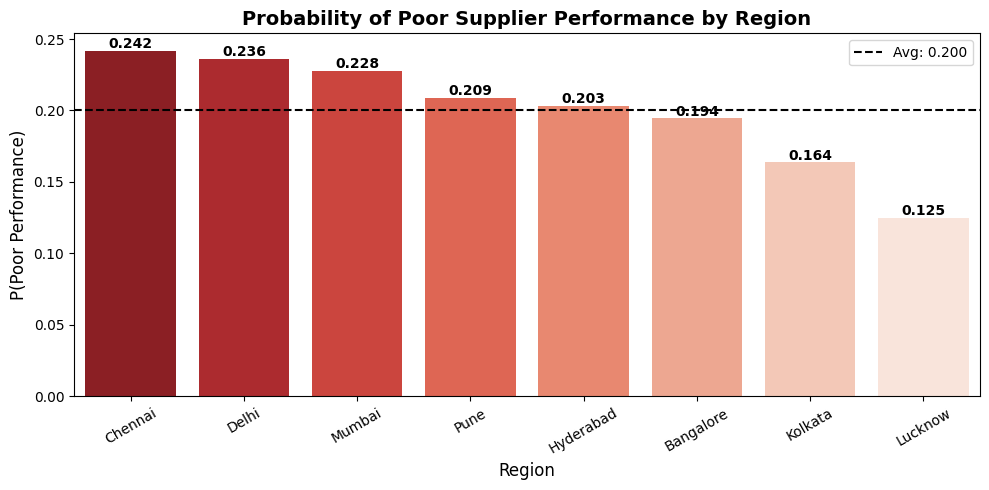

In [12]:
# Plot 
lb.plt.figure(figsize=(10, 5))
lb.sns.barplot(data=poor_perf,
               x='Region',
               y='P_Poor_Performance',
               palette='Reds_r')

for i, row in poor_perf.reset_index().iterrows():
    lb.plt.text(i, row['P_Poor_Performance'] + 0.002,
                f"{row['P_Poor_Performance']:.3f}",
                ha='center', fontsize=10, fontweight='bold')

lb.plt.axhline(y=poor_perf['P_Poor_Performance'].mean(),
               color='black', linestyle='--',
               label=f"Avg: {poor_perf['P_Poor_Performance'].mean():.3f}")

lb.plt.title('Probability of Poor Supplier Performance by Region',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Region', fontsize=12)
lb.plt.ylabel('P(Poor Performance)', fontsize=12)
lb.plt.xticks(rotation=30)
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()

## Observation

**Chennai (0.242)** highest poor performance 1 in 4 suppliers underperform.

**Delhi (0.236) & Mumbai (0.228)** follow metro city suppliers surprisingly unreliable.

**Lucknow (0.125)** best performing lowest poor performance probability.

**Avg P(Poor Performance) = 0.200** 20% of all suppliers perform poorly.

**Key Insight:** 

1 in 5 suppliers across all regions underperform supplier evaluation and replacement strategy needed.

#  P(Below Reorder Level) by Category

In [13]:
inventory_data['Reorder_Flag_Int'] = inventory_data['Reorder_Flag'].astype(int)

reorder_prob = inventory_data.groupby('Category').agg(
    Total_Records=('Reorder_Flag_Int', 'count'),
    Reorder_Count=('Reorder_Flag_Int', 'sum')
).reset_index()

reorder_prob['P_Below_Reorder'] = (
    reorder_prob['Reorder_Count'] /
    reorder_prob['Total_Records']
).round(4)

reorder_prob = reorder_prob.sort_values('P_Below_Reorder', ascending=False)
print(reorder_prob.to_string())

            Category  Total_Records  Reorder_Count  P_Below_Reorder
4         Parenteral            181              8           0.0442
0  Bulk/Raw Material             26              1           0.0385
3              Other            445             14           0.0315
1               Oral            186              4           0.0215
2        Oral Liquid              3              0           0.0000


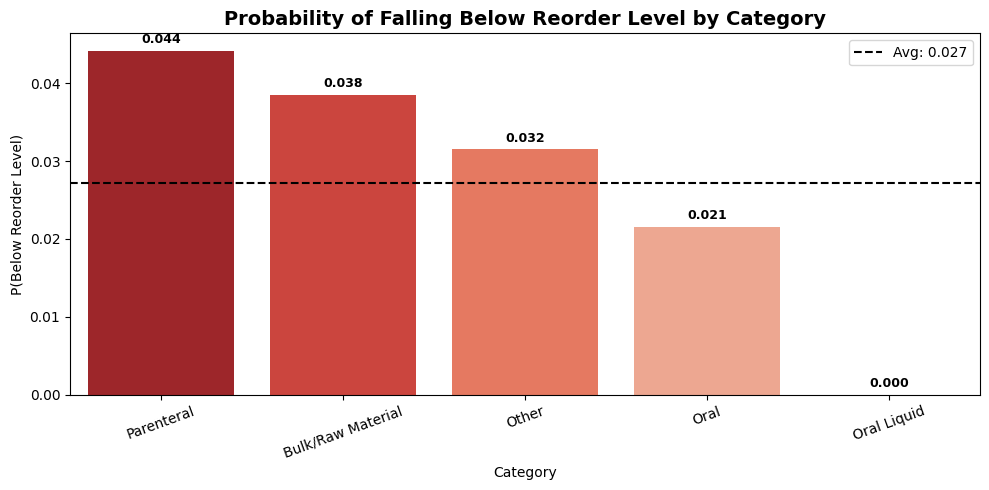

In [14]:
# Plot
lb.plt.figure(figsize=(10, 5))
bars = lb.sns.barplot(data=reorder_prob,
                      x='Category',
                      y='P_Below_Reorder',
                      palette='Reds_r')

for i, row in reorder_prob.reset_index().iterrows():
    lb.plt.text(i, row['P_Below_Reorder'] + 0.001,
                f"{row['P_Below_Reorder']:.3f}",
                ha='center', fontsize=9, fontweight='bold')

lb.plt.axhline(y=reorder_prob['P_Below_Reorder'].mean(),
               color='black', linestyle='--',
               label=f"Avg: {reorder_prob['P_Below_Reorder'].mean():.3f}")

lb.plt.title('Probability of Falling Below Reorder Level by Category',
             fontsize=14, fontweight='bold')
lb.plt.xlabel('Category')
lb.plt.ylabel('P(Below Reorder Level)')
lb.plt.xticks(rotation=20)
lb.plt.legend()
lb.plt.tight_layout()
lb.plt.show()